# **DISCREPANCY AND THE KOKSMA-HAWKA INEQUALITY**
## **THEOREM:**
- We have an error estimate despite leaving aside for that the error is in probability:
$$
|\frac{1}{n} \sum_{i=1}^{n} f(x_i) - \int_{[0, 1]^d} f(x)dx| \leq V(f) D^{*}(x_1, \dots, x_n)
$$

- Where V(h) is the Hardy-Krause Variation in d dimensions of the function f. 


- **MOTIVATION**
- The randomnes of the sequence isn't important for the MC integration, in the following sense:
- if we have a number sequence $ \{x_i\}_{i=1,\dots,n} $ and we calculate its Monte Carlo Integration: $\frac{1}{n} \sum_{i=1}^{n} f(x_i)$, so it doesn't matter if $x_i$ occurs in a random order. (even we could sort the sequence and the MC integral would remain the same). 
- So, we are actully not so much intersested in the *randomness* of a random number sequence. 
- A more important property is the ***discrepancy***, which leads to the definition of *low discrepancy sequence*


### **PROOF:**
- Implement another Monte Carlo integration in 1D using a special, non-random sequence, namely the *equi-distant partitioning*

$$
x_i= \frac{1}{n} \to \text{Left Point - Quasi Monte Carlo Integration}
$$

$$
x_i = \frac{2i + 1}{2n}, \quad i = 0, \ldots, n - 1 \quad \to \quad \text{Midpoint / Quasi Monte Carlo Integration}
$$


In [1]:
from MonteCarlo import Integrator1DExperiment

In [2]:
a = Integrator1DExperiment()

Testing several implementations of a 1D integrator.
              (Note that some implementations may use Kahan summation or similar techniques.)
Number of evaluation points....: 10001 (≈ 1.00e+04)

Theoretical (relative) errors are:
	Monte-Carlo integration.......(1/n)^0.5..: 1.00e-02
	Simpson's rule integration....(1/n)^4....: 1.00e-16

SimpsonsIntegrator1D                         -0.9589242746631377  ± 7.772e-16
SimpsonsIntegrator1DWithStreams              -0.9589242746631389  ± 4.441e-16
MonteCarloIntegrator1D                       -0.9921573721286792  ± 3.323e-02
MonteCarloIntegrator1DWithStreams            -0.9523324603356010  ± 6.592e-03
QuasiMonteCarloIntegrator1D                  -0.9587451881425600  ± 1.791e-04
QuasiMonteCarloIntegrator1DWithStreams       -0.9587451881425647  ± 1.791e-04
RiemannMidPointIntegrator1D                  -0.9589242846499322  ± 9.987e-09
RiemannMidPointIntegrator1DWithStreams       -0.9589242846499356  ± 9.987e-09


> For the SimpsonsIntegrator1D and SimpsonsIntegrator1DWithStreams, the numerical errors are: $O(1/n)^4$

> For the SimpsonsIntegrator1D and SimpsonsIntegrator1DWithStreams, the numerical errors are: $O(1/n)^{1/2}$

> For the QuasiMonteCarloIntegrator1D and QuasiMonteCarloIntegrator1DWithStreams, the numerical errors are: $O(1/n)$

> For the RiemannMidPointIntegrator1D and RiemannMidPointIntegrator1DWithStreams, the numerical errors are: $O(1/n^2)$

- So, How many points would you expect in an empty area

<p align="center">
<img src='image-7.png' alt='alt-text' width=600 height=400>
</p>

### **Definition 37 (Discrepancy, Star Discrepancy)**

Let $\{x_1, \ldots, x_n\} \subset [0,1]^d$. The **general discrepancy** $D(x_1, \ldots, x_n)$ is given by

$$
D(x_1, \ldots, x_n) := \sup_{\vec{a}, \vec{b} \in [0,1]^d} \left| \frac{|\{x_i \mid x_i \in [\vec{a}, \vec{b}]\}|}{n} - \lambda([\vec{a}, \vec{b}]) \right|,
$$

where:

- $[\vec{a}, \vec{b}] := [a_1, b_1] \times \cdots \times [a_d, b_d]$
- $\lambda([\vec{a}, \vec{b}]) := \prod_{i=1}^d |b_i - a_i|$
- $|\{x_i \mid x_i \in [\vec{a}, \vec{b}]\}|$ is the number of $x_i$ such that $x_i \in [\vec{a}, \vec{b}]$

---

The **star discrepancy** $D^*(x_1, \ldots, x_n)$ is given by considering $\vec{a} = 0$, i.e.,

$$
D^*(x_1, \ldots, x_n) := \sup_{\vec{b} \in [0,1]^d} \left| \frac{|\{x_i \mid x_i \in [0, \vec{b}]\}|}{n} - \lambda([0, \vec{b}]) \right|.
$$

> The percentage of points that we observe in the given interval $\vec{a}$ to $\vec{b}$: $\frac{|\{x_i \mid x_i \in [\vec{a}, \vec{b}]\}|}{n}$

> The Volume of the interval $\vec{a}$ to $\vec{b}$: $\lambda([\vec{a}, \vec{b}])=\prod_{i=1}^d |b_i - a_i|$

> Where, **sup** is a mathematical notation for the supremum, which is the least upper bound of a set. *And in this case we are looking for the worst case that is the maximum absolute value in the difference*. ***THUS, THE SUPREAM CAPTURES MAXIMUM DISCREPANCY BETWEEN THE DISTRIBUTION OF THE POINTS AND THE UNIFORM DISTRIBUTION OF THE CUBE***

> So, the **star discrepancy** is a lower bound because you just have a special selection of volume, but also an upper bound with a certain constant. So, for our characterization actually the star discrpancy is enough and you don't need to check all possible end points because you just need to check a single point and then take the volume from zero to a single points.

> $D^*(x_1, ..., x_n) \geq D(x_1, ..., x_n) \geq 2^d*D^*(x_1, ..., x_n)$


An elementary method for exact calculation of the star discrepancy is given by the following formula:  

For $X := \{x_1, \dots, x_n\} \subset [0,1]^d$ set $\Gamma_j(X) := \{x_{i,j} \mid i = 1, \dots, n\} \cup 1$ for $j = 1, \dots, d$ and  
$\Gamma(X) := \Gamma_1 \times \cdots \times \Gamma_d$. Then

$$
D^*(x_1, \dots, x_n) = \max_{x \in \Gamma(X)} \max\left( \lambda([0,x)) - \frac{|[0,x) \cap X|}{n}, \, \frac{|[0,x] \cap X|}{n} - \lambda([0,x]) \right).
$$

Thus $D^*$ can be calculated by considering at most $2(n+1)^d$ test intervals.
<p align="center">
<img src='image-8.png' alt='alt-text' width=400 height=250>
</p>

> The algorithm is that I always check the locations where I jump across a point. 

- Now I have to do it in every Dimension and for this there is a set gamma $\Gamma_j$; that is taken the sequence that you have 
- For example, we set first the sequence $X := \{x_1, x_2\}$ and then we set $\Gamma_1$ and $\Gamma_2$ for calculating the cartesian product $\Gamma(X) := \Gamma_1 \times \Gamma_2$.

<p align="center">
<img src='image-9.png' alt='alt-text' width=300 height=250>
</p>

### **THEOREM: (KOKSMA-HLAWKA INEQUALITY):**
If f has bounded (total) variation on the unit hyper cube in *d* dimensions, then for any points $\{x_1, ..., x_n\} \subset [0, 1]^d$, in said unit hypercube, we have:
$$
|\frac{1}{n} \sum_{i=1}^{n} f(x_i) - \int_{[0, 1]^d} f(x)dx| \leq V(f) D^{*}(x_1, \dots, x_n)
$$

where $V(f)$ is the Hardy-Krause variation of f in d dimensions of the function f.
- $V(f):$ Take the role of $\sigma= \sqrt{Var(f(x))}$
- $D^*(x_1, \dots, x_n):$ takes the of $\frac{1}{\sqrt{n}}$

If we go to one dimension, we can nicely see what is done:
- Examples: We have an X in the interval $[0,1]$, $0 \leq x < 1$

<p align="center">
<img src='image-10.png' alt='alt-text' width=600 height=250>
</p>

In [3]:
import matplotlib.pyplot as plt
import math as mt
import random as rng
import numpy as np

In [6]:
class DiscrepancyExperiment:
    @staticmethod
    def analyze(label, samples):
        D = DiscrepancyExperiment.getDiscrepancy(samples)
        print(f"{label:>32} \t D = {D:.6f}")
        DiscrepancyExperiment.plotDiscrepancyFunction(label, samples)

    @staticmethod
    def getDiscrepancy(samples):
        sample_sorted = sorted(samples)
        discrepance = 0.0
        count = 0

        for sample in sample_sorted: #For a sample point x_i ... 
            low = sample - count/len(samples) #... evaluate lambda([0,x)) - i/n = x - i/n ...
            count = count + 1 #... and (i+i)/n - lambda([0,x]) = i+1/n - x ...
            high = count/len(samples) - sample

            discrepance = max(discrepance, max(low, high))

        return discrepance
    
    @staticmethod
    def plotDiscrepancyFunction(label, samples):
        n = len(samples)
        samples = np.array(samples)

        def lambda_diff(x):
            return x - np.sum(samples < x) / n
        
        x_val = np.linspace(0, 1, 1000)
        y_val = [lambda_diff(x) for x in x_val]

        plt.figure(figsize=(30, 10))
        plt.plot(x_val, y_val, label = 'λ([0,x)) - empírical')
        plt.scatter(samples, np.zeros_like(samples), color = 'brown', label='sample')
        plt.ylim(-0.5, 0.5)
        plt.title(label)
        plt.xlabel('x')
        plt.ylabel('λ([0,x)) - |xᵢ ∈ [0,x)| / n')
        plt.grid(True)
        plt.legend()
        plt.show()

    @staticmethod
    def __init__():
        print("\nRandom, n=5")
        np.random.seed(3216)
        samples = np.random.rand(5).tolist()
        DiscrepancyExperiment.analyze("Random, n=5", samples)

        print("\nRefined sets")
        DiscrepancyExperiment.analyze("Refined left to right, n=5",
                                    [1.0/8, 2.0/8, 3.0/8, 2.0/4, 3.0/4])
        
        DiscrepancyExperiment.analyze("Refined like v.d.C., n=5",
                                    [1.0/8, 2.0/8, 2.0/4, 5.0/8, 3.0/4])


Random, n=5
                     Random, n=5 	 D = 0.461166


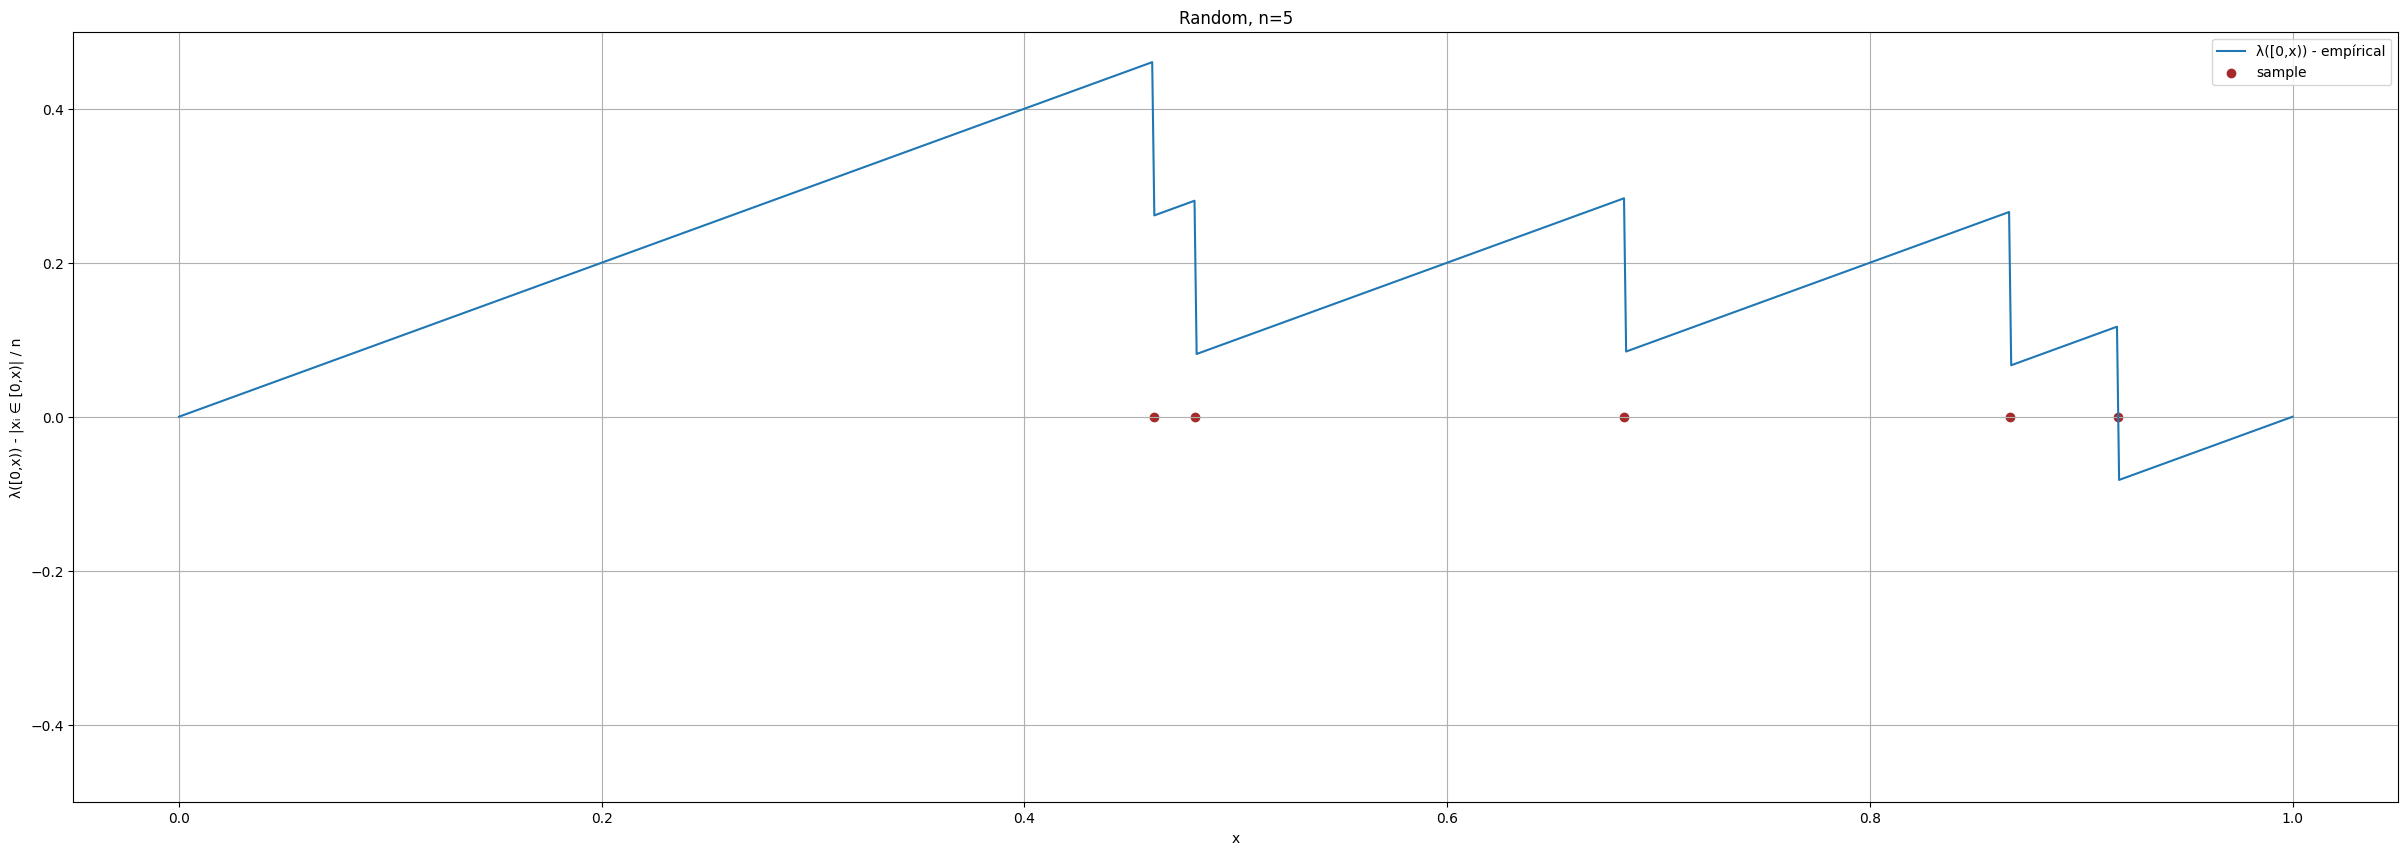


Refined sets
      Refined left to right, n=5 	 D = 0.300000


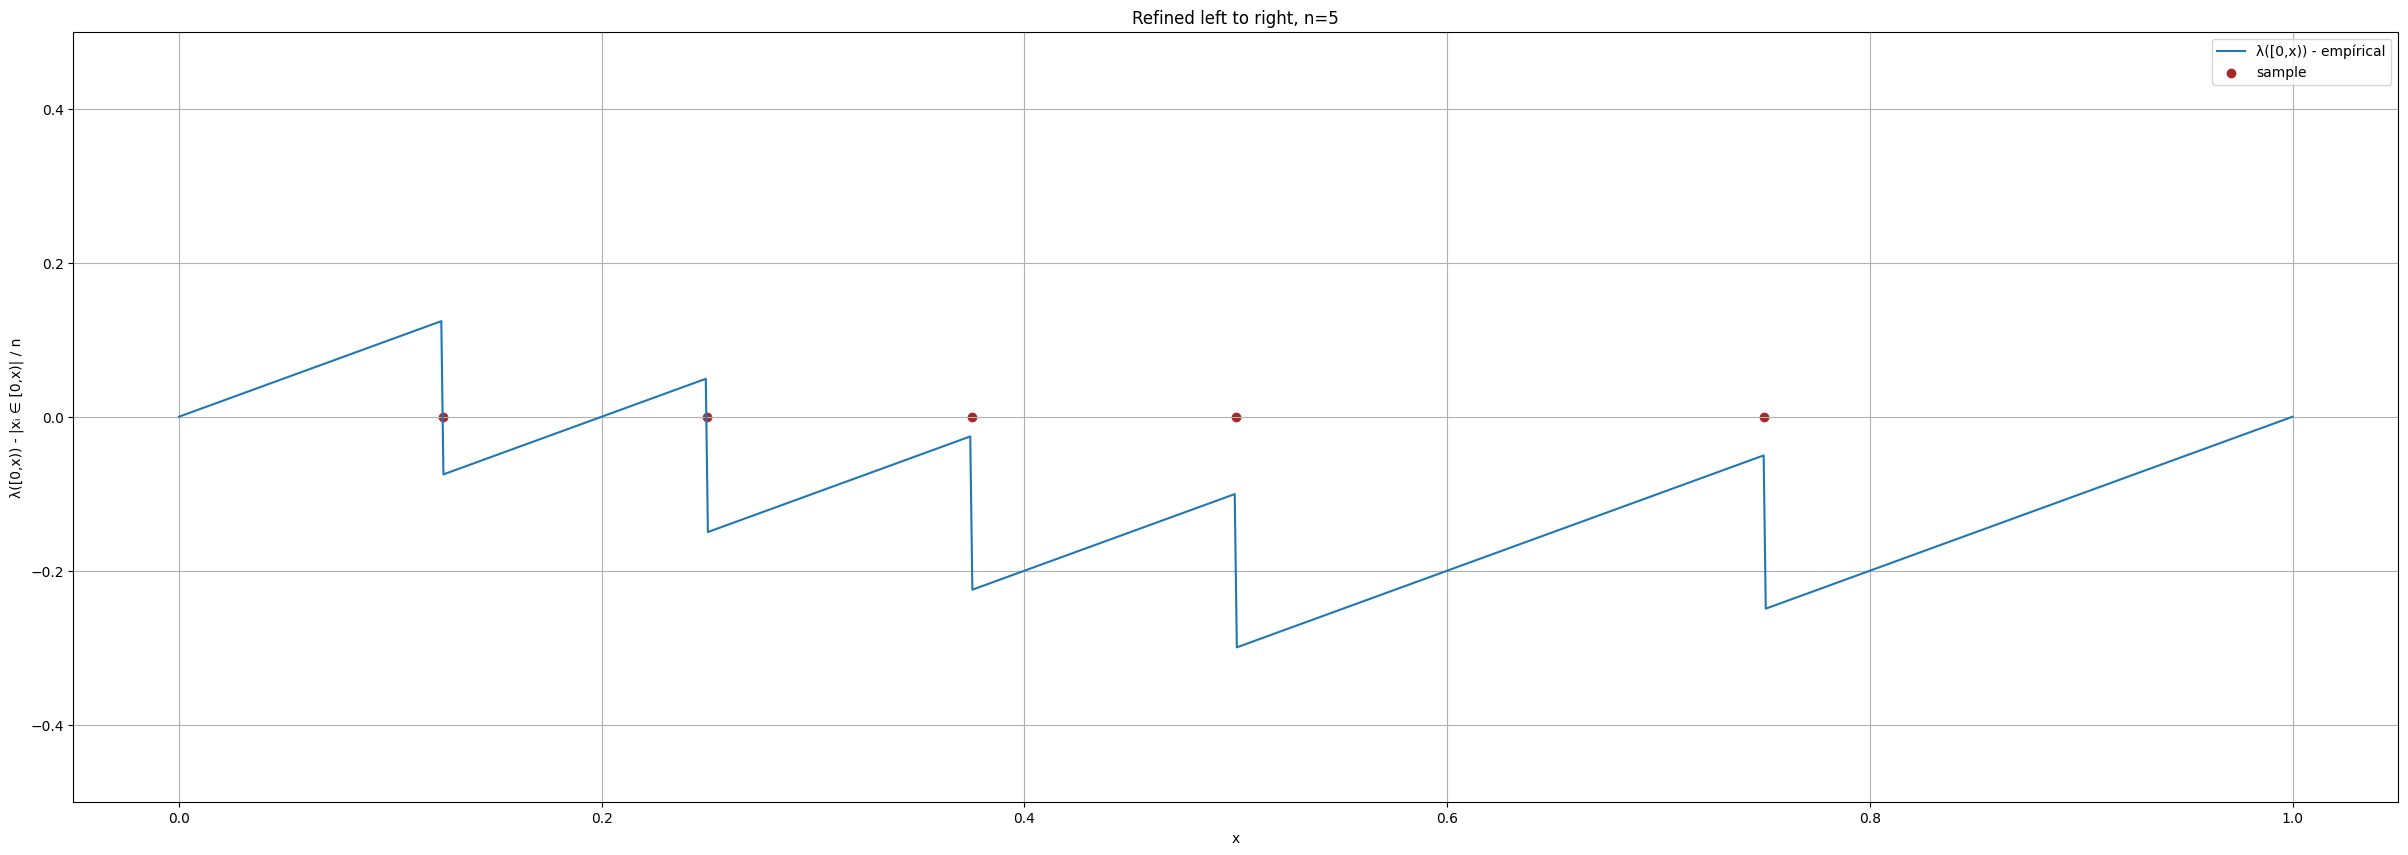

        Refined like v.d.C., n=5 	 D = 0.250000


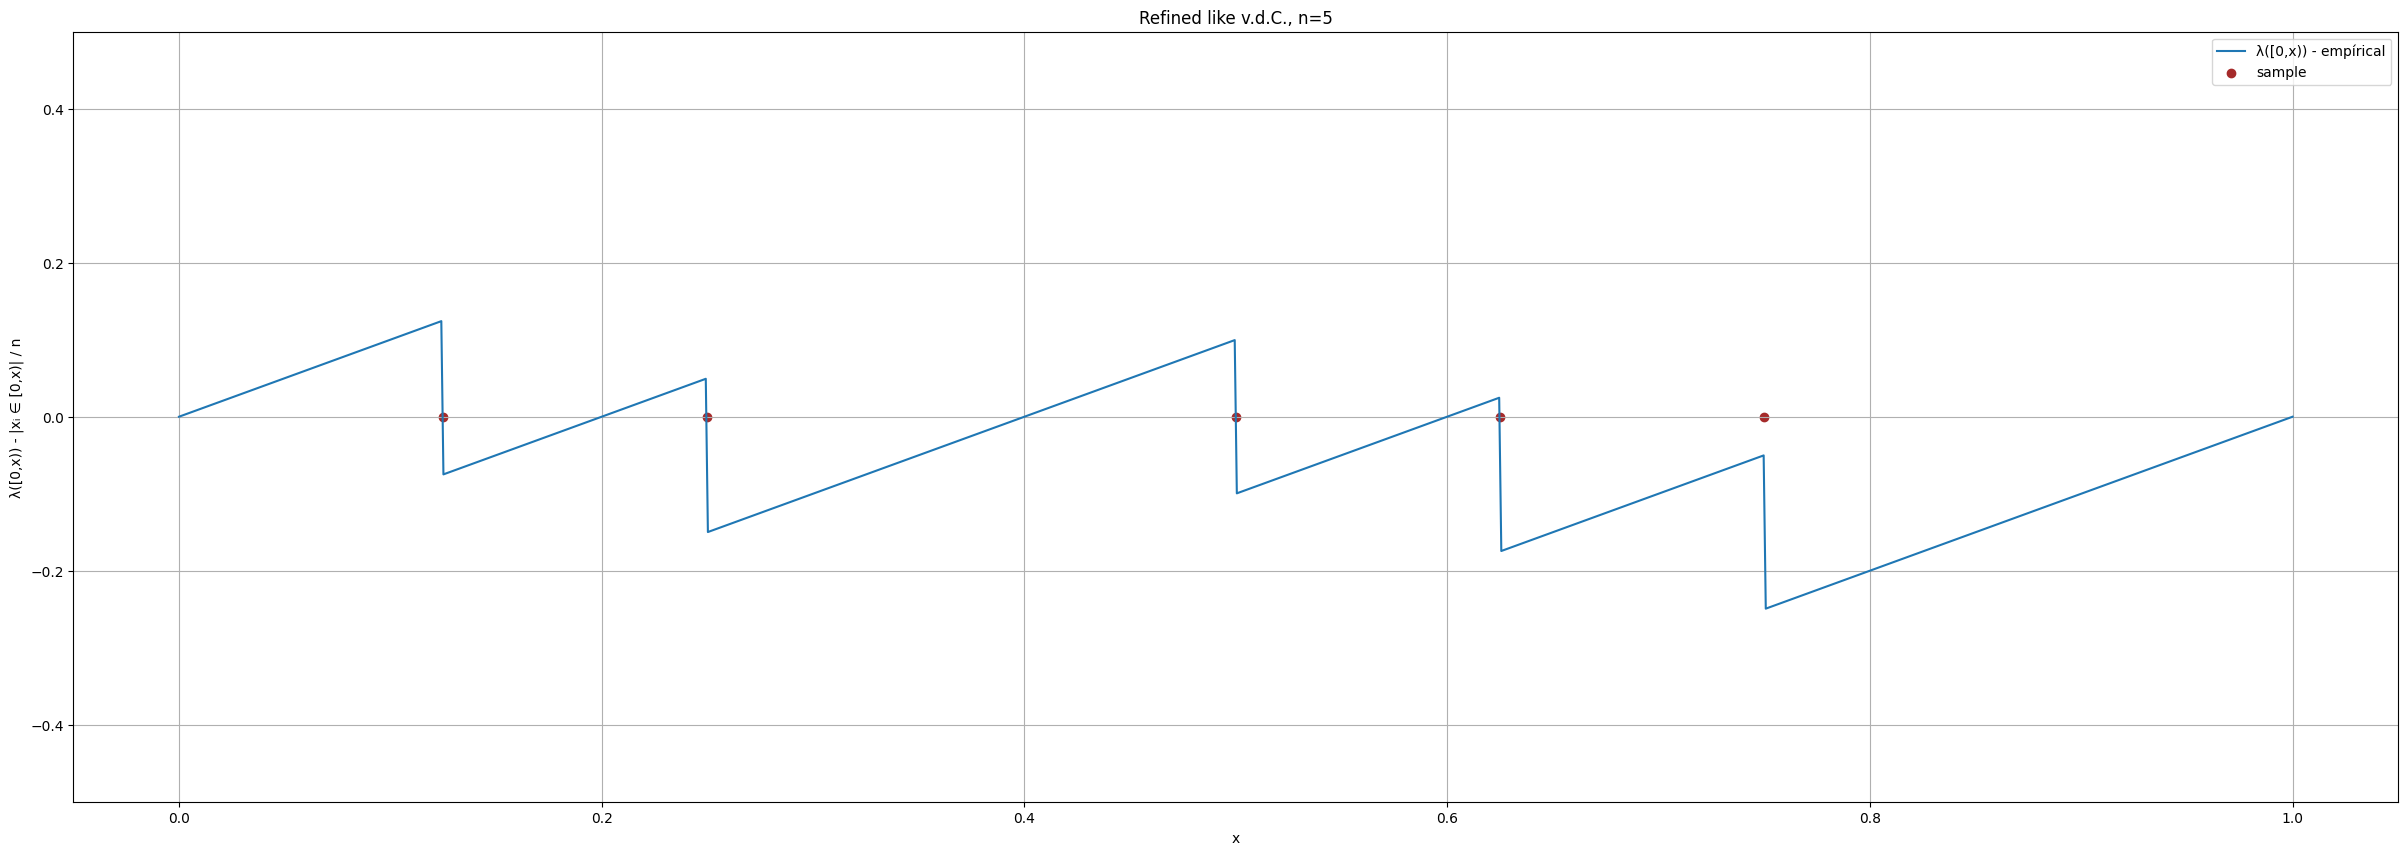


Random, n=5
                     Random, n=5 	 D = 0.461166


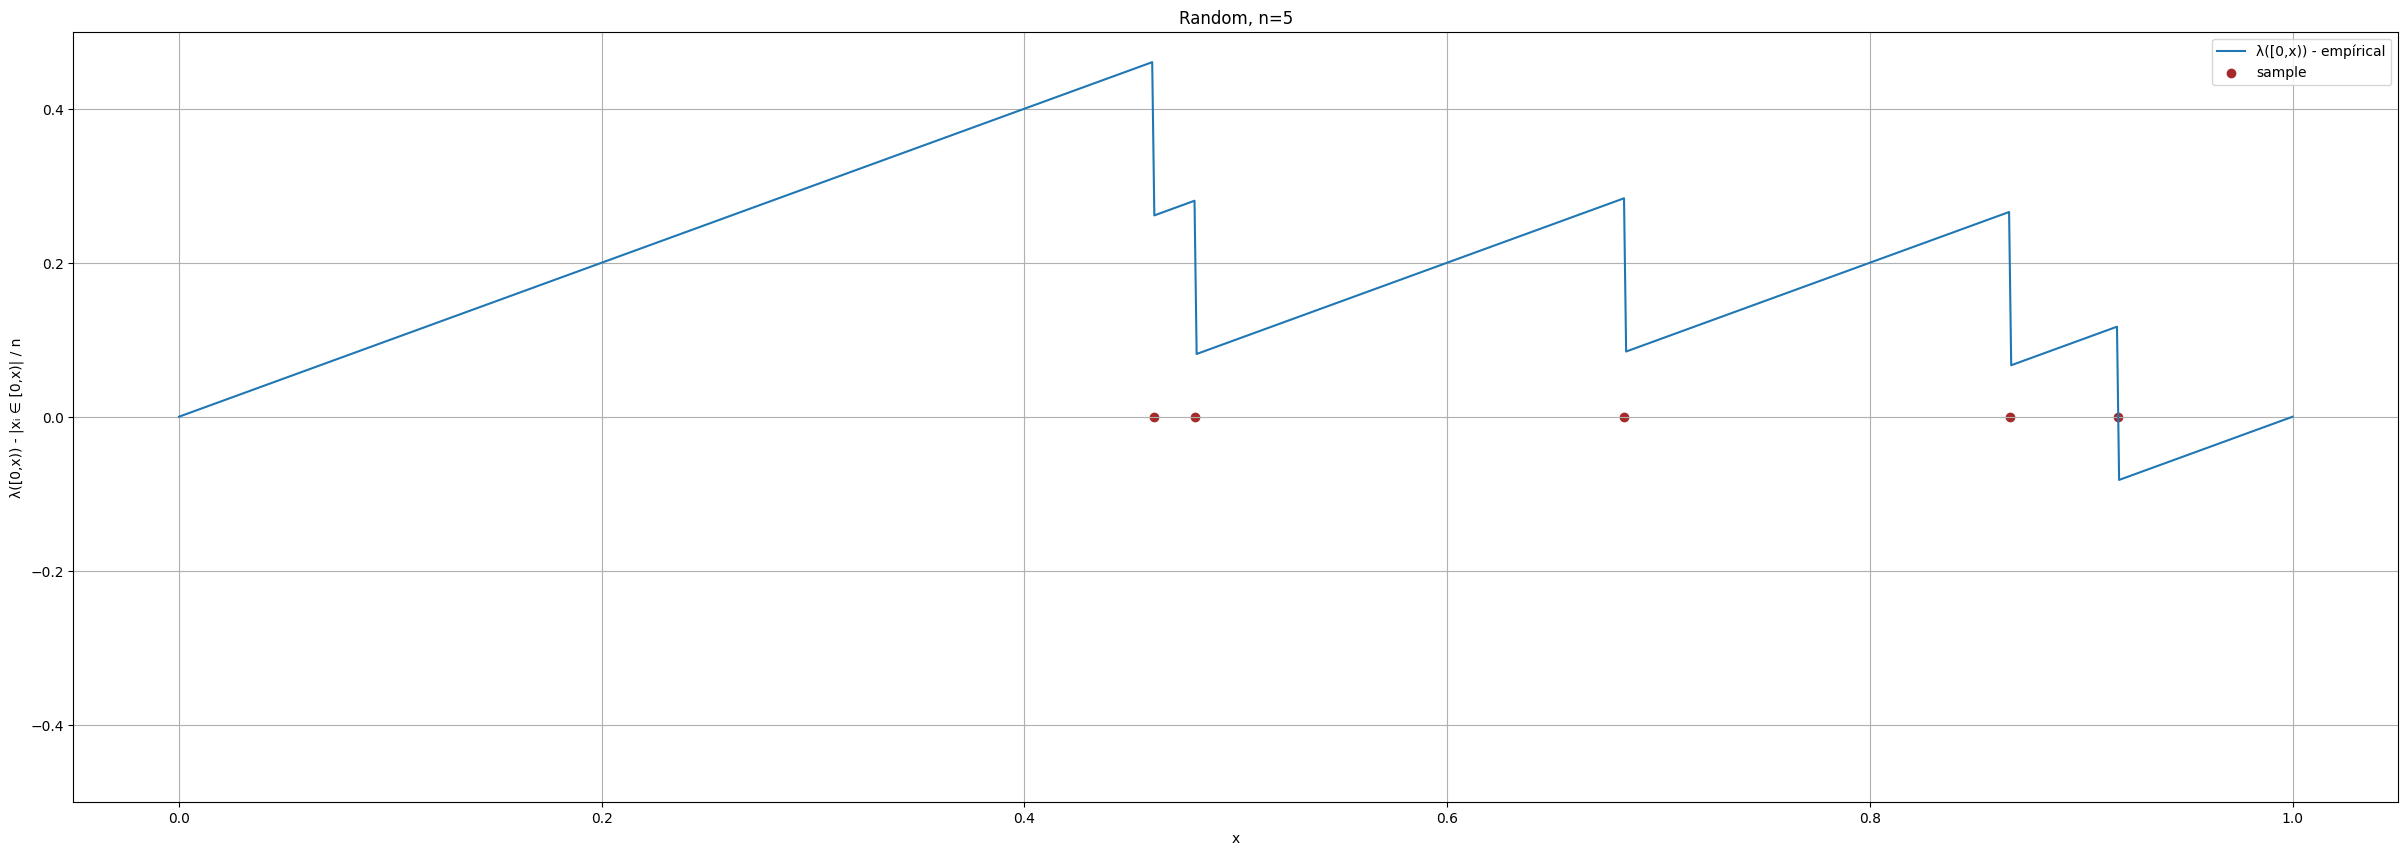


Refined sets
      Refined left to right, n=5 	 D = 0.300000


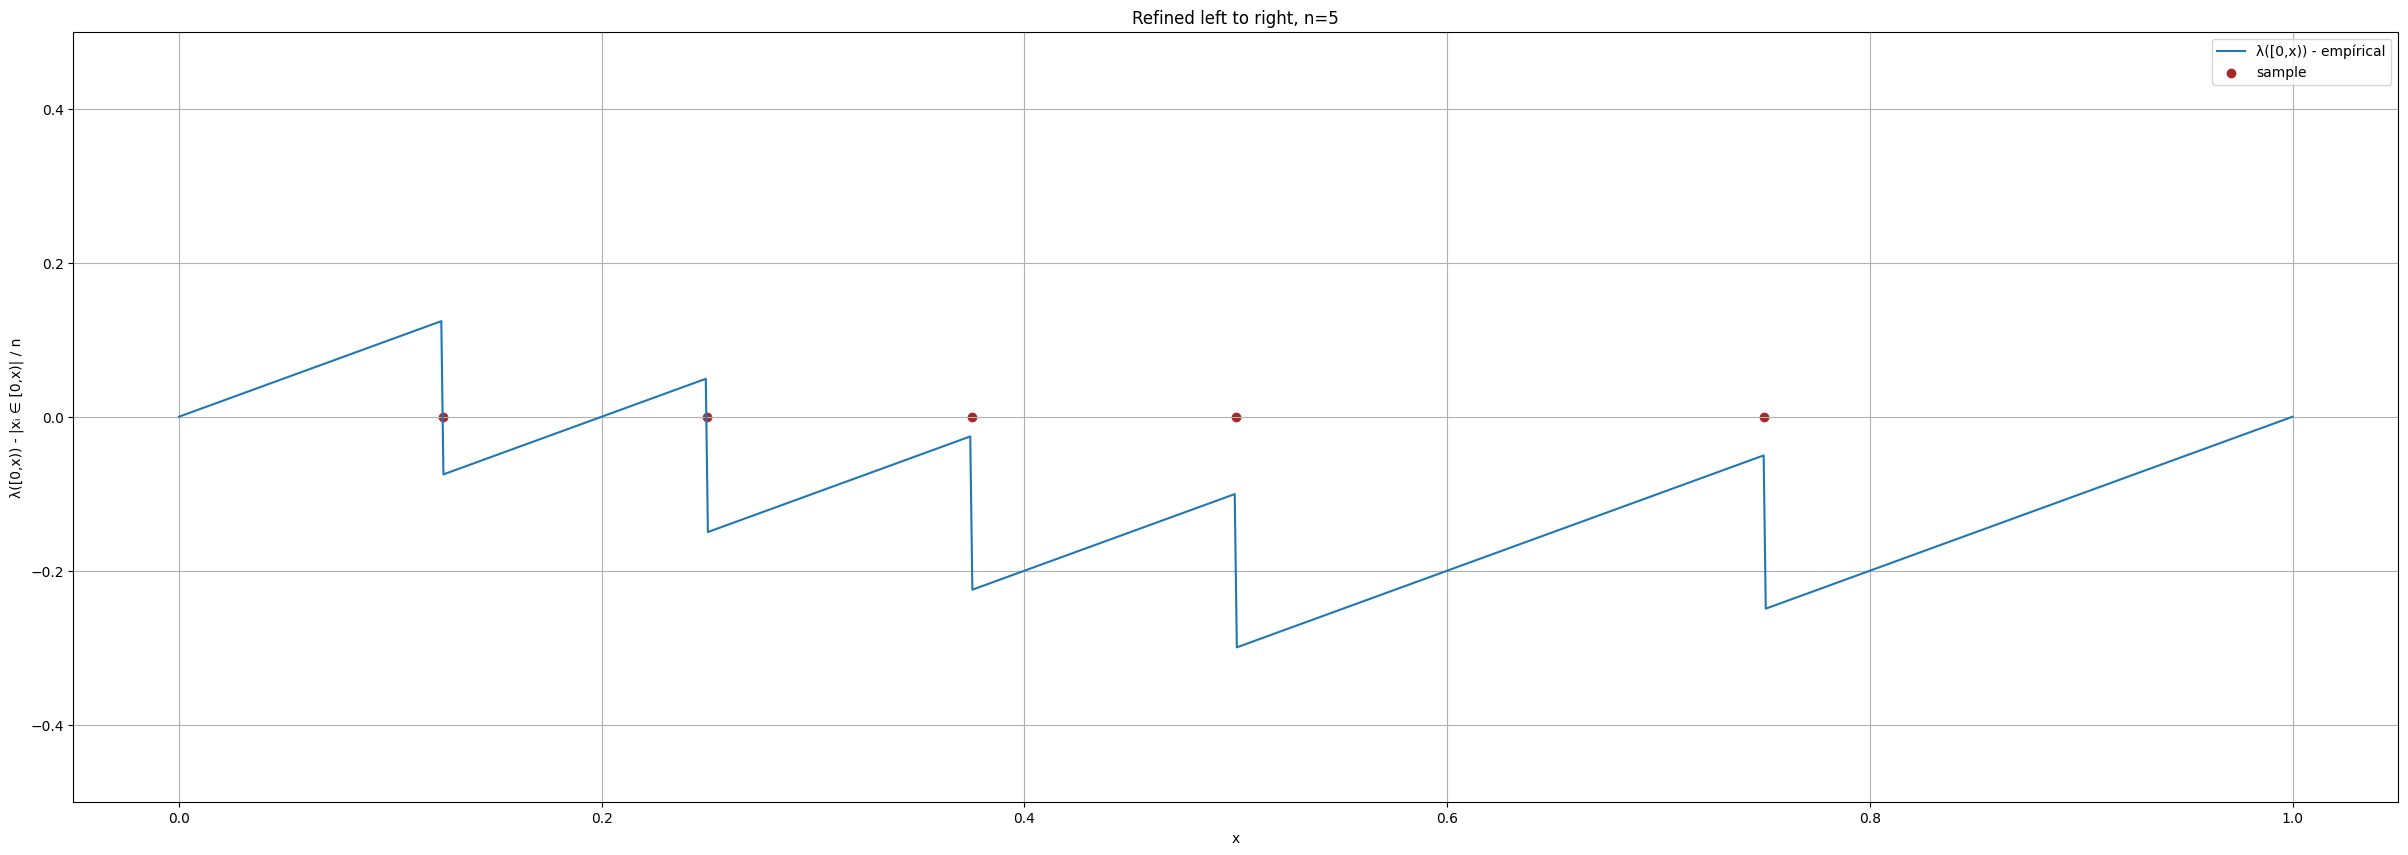

        Refined like v.d.C., n=5 	 D = 0.250000


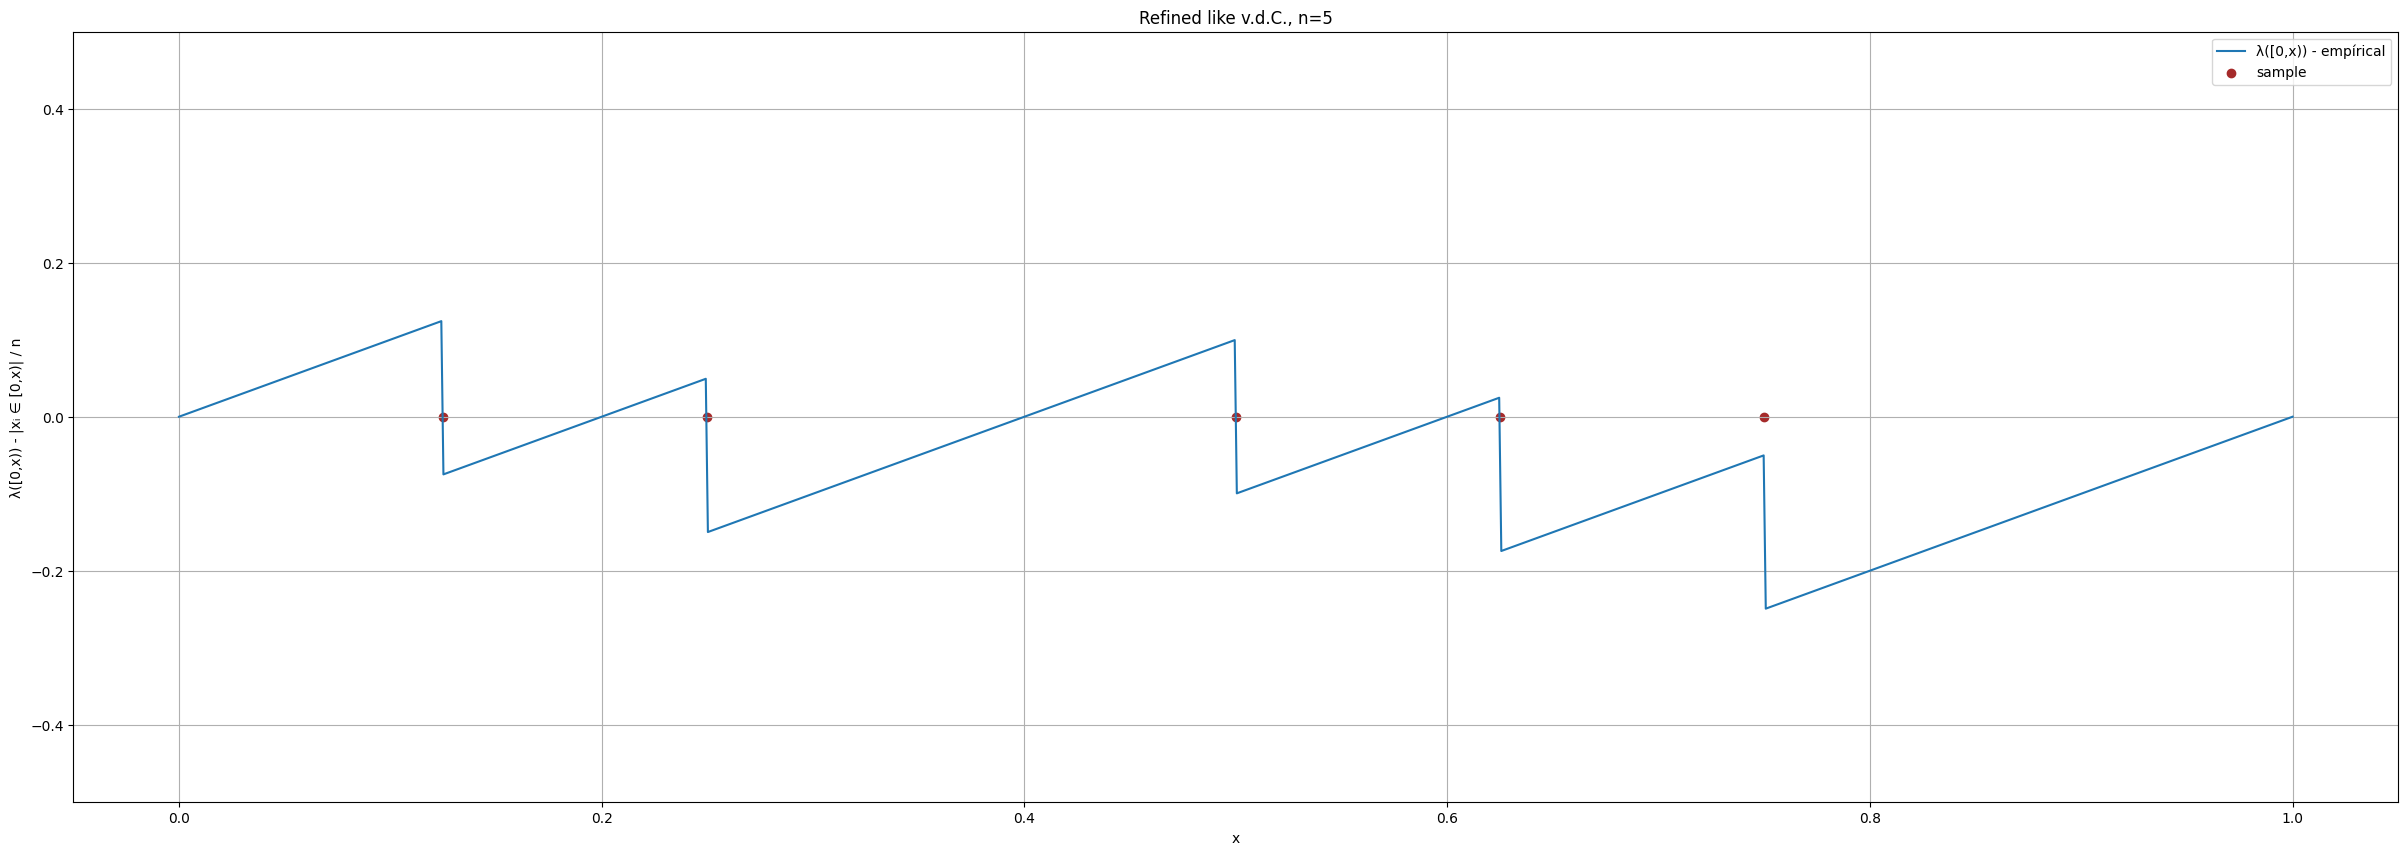

In [7]:
discrepancy = DiscrepancyExperiment()
discrepancy.__init__()